In [3]:
import xgboost as xgb
import shap
print("xgboost version:", xgb.__version__)
print("shap version:", shap.__version__)

xgboost version: 3.2.0
shap version: 0.51.0


# **Weeks 5, 6 and 7** 
**ML training and Result Plots**

Models trained for:
- **Core temperature** (target from `features_cycle_with_core_fixed.parquet` if present, else `features_cycle_with_core.parquet`)
- **SOH** (if available; otherwise an *explicitly-labelled* `SOH_proxy` will be created from `energy_sum` — only used for exploratory training)

Features:
- Uses `data_processed/features_cycle_with_core_fixed.parquet` when present (safe fallback to the standard file).
- Checkpointed/resumable: progress stored in `models_week5_7/progress_week5_7.json` and per-target preproc files.
- Models and figures saved to `models_week5_7/` and `figures_week5_7/`.
- Publication-quality figures saved at 300 dpi.

In [9]:
pip install "numpy<2"

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Cell 2 - imports and basic setup
import os, time, json, joblib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# Optional heavy libraries
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception:
    xgb = None
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    shap = None
    SHAP_AVAILABLE = False

warnings.filterwarnings("ignore")

# Output directories
OUT_DIR = Path("models_week5_7"); OUT_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR = Path("figures_week5_7"); FIG_DIR.mkdir(exist_ok=True, parents=True)

# Feature files (prefer fixed parquet)
FEAT_FP_FIXED = Path("data_processed/features_cycle_with_core_fixed.parquet")
FEAT_FP_STD   = Path("data_processed/features_cycle_with_core.parquet")
FEAT_FP = FEAT_FP_FIXED if FEAT_FP_FIXED.exists() else FEAT_FP_STD

PROCESSED_PREP_FP = OUT_DIR / "preprocessed_train_test.joblib"
PROGRESS_FP = OUT_DIR / "progress_week5_7.json"

# Runtime knobs
RANDOM_SEED = 42
SAMPLE_MODE = False
SAMPLE_FRAC = 0.05
GROUP_K = 5
N_JOBS = max(1, (psutil.cpu_count(logical=False) or 1) - 0)

np.random.seed(RANDOM_SEED)

print("Using features file:", FEAT_FP)
print("XGBoost available:", XGBOOST_AVAILABLE, "SHAP available:", SHAP_AVAILABLE)
print("Sample mode:", SAMPLE_MODE, "Sample frac:", SAMPLE_FRAC, "N_JOBS:", N_JOBS)

# Progress helpers
def load_progress():
    if PROGRESS_FP.exists():
        return json.loads(PROGRESS_FP.read_text())
    else:
        p = {"preprocessed": False, "baseline_done": [], "tuned_done": [], "explain_done": False}
        PROGRESS_FP.write_text(json.dumps(p))
        return p

def save_progress(progress):
    PROGRESS_FP.write_text(json.dumps(progress))

Using features file: data_processed/features_cycle_with_core_fixed.parquet
XGBoost available: True SHAP available: True
Sample mode: False Sample frac: 0.05 N_JOBS: 16


In [2]:
# Cell 3 - plotting and small helpers
import math
from pathlib import Path

sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def save_fig(fig, fp, dpi=300):
    fp = Path(fp); fp.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(fp, dpi=dpi, bbox_inches='tight')
    plt.close(fig)

def parity_plot(y_true, y_pred, title, out_fp=None):
    fig, ax = plt.subplots(figsize=(6,5))
    ax.scatter(y_true, y_pred, s=10, alpha=0.6, c='tab:blue')
    mn = min(np.nanmin(y_true), np.nanmin(y_pred)); mx = max(np.nanmax(y_true), np.nanmax(y_pred))
    ax.plot([mn,mx],[mn,mx],'--k', linewidth=1)
    ax.set_xlabel("True"); ax.set_ylabel("Pred"); ax.set_title(title)
    if out_fp: save_fig(fig, out_fp)

def resid_plot(y_true, y_pred, title, out_fp=None):
    res = np.array(y_pred) - np.array(y_true)
    fig, ax = plt.subplots(figsize=(6,3))
    ax.hist(res, bins=60, alpha=0.9)
    ax.set_title(title)
    if out_fp: save_fig(fig, out_fp)

In [3]:
# Cell 4 - load features, apply zero->NaN, sample, and group split
progress = load_progress()
if progress.get("preprocessed", False) and PROCESSED_PREP_FP.exists():
    print("Loading preprocessing checkpoint:", PROCESSED_PREP_FP)
    prep = joblib.load(PROCESSED_PREP_FP)
    feat_df = prep['feat_df']
    train_df = prep['train_df_raw']
    test_df  = prep['test_df_raw']
    print("Loaded checkpoint. Train rows:", len(train_df), "Test rows:", len(test_df))
else:
    feat_df = pd.read_parquet(FEAT_FP)
    print("Loaded features:", feat_df.shape)

    # Zero -> NaN conversion (conservative)
    ZERO_TO_NA = True
    if ZERO_TO_NA:
        numeric_cols_all = feat_df.select_dtypes(include=[np.number]).columns.tolist()
        zero_to_na_cols = []
        for c in numeric_cols_all:
            try:
                z_frac = (feat_df[c] == 0).mean()
                if (z_frac > 0) and (z_frac < 0.5) and (feat_df[c].mean() > 0):
                    zero_to_na_cols.append(c)
            except Exception:
                continue
        if zero_to_na_cols:
            print("Zero->NaN applied to columns:", zero_to_na_cols)
            feat_df[zero_to_na_cols] = feat_df[zero_to_na_cols].replace(0, np.nan)
        else:
            print("Zero->NaN: no columns matched heuristic.")

    # sampling for quick runs
    df_work = feat_df
    if SAMPLE_MODE:
        unique_cells = df_work['cell_id'].unique()
        sampled_cells = np.random.choice(unique_cells, max(1,int(len(unique_cells)*SAMPLE_FRAC)), replace=False)
        df_work = df_work[df_work['cell_id'].isin(sampled_cells)].reset_index(drop=True)
        print("Sample mode: rows:", len(df_work))

    # grouped holdout split
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_SEED)
    groups = df_work['cell_id'].values
    train_idx, test_idx = next(gss.split(df_work, groups=groups))
    train_df = df_work.iloc[train_idx].reset_index(drop=True)
    test_df  = df_work.iloc[test_idx].reset_index(drop=True)
    print("Train rows:", len(train_df), "Test rows:", len(test_df))

    # checkpoint preprocessing
    prep = {'feat_df': feat_df, 'train_df_raw': train_df, 'test_df_raw': test_df}
    joblib.dump(prep, PROCESSED_PREP_FP)
    print("Saved preprocessing checkpoint:", PROCESSED_PREP_FP)
    progress['preprocessed'] = True
    save_progress(progress)

Loading preprocessing checkpoint: models_week5_7/preprocessed_train_test.joblib
Loaded checkpoint. Train rows: 1837 Test rows: 99


In [4]:
# Cell 5 - fully patched with interactive progress bar for tuning
from sklearn.pipeline import make_pipeline
from datetime import datetime
from tqdm import tqdm  # for progress bars

def run_training_pipeline(target_col, suffix, sample_mode=SAMPLE_MODE, sample_frac=SAMPLE_FRAC, do_tuning=True, tuning_n_iter=12):
    """
    Runs pipeline for a single target (baseline models, permutation importance, optional tuning).
    Checkpoints baseline and tuned models and updates PROGRESS_FP.
    Prints live progress updates during training/tuning with progress bar.
    """
    def now(): return datetime.now().strftime("%H:%M:%S")
    
    progress = load_progress()
    print(f"\n[{now()}] === PIPELINE START: {suffix} (target={target_col}) ===")

    # reload features
    feat_df_all = pd.read_parquet(FEAT_FP)
    df = feat_df_all[feat_df_all[target_col].notna()].reset_index(drop=True)
    print(f"[{now()}] Total rows with target:", len(df))

    # sampling
    if sample_mode:
        unique_cells = df['cell_id'].unique()
        sampled_cells = np.random.choice(unique_cells, max(1,int(len(unique_cells)*sample_frac)), replace=False)
        df = df[df['cell_id'].isin(sampled_cells)].reset_index(drop=True)
        print(f"[{now()}] Sampled df rows:", len(df))

    # features
    non_features = {'cell_id','cycle','dataset','chemistry'}
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numeric_cols: numeric_cols.remove(target_col)
    features_list = [c for c in numeric_cols if c not in non_features]
    df = df[features_list + [target_col, 'cell_id']]
    nunique = df[features_list].nunique()
    features_list = nunique[nunique > 1].index.tolist()
    if len(features_list) == 0: raise ValueError("No numeric features left after removing constants")
    print(f"[{now()}] Number of features used (non-constant): {len(features_list)}")

    # train/test split
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_SEED)
    train_idx, test_idx = next(gss.split(df, groups=df['cell_id'].values))
    train_df_loc = df.iloc[train_idx].reset_index(drop=True)
    test_df_loc  = df.iloc[test_idx].reset_index(drop=True)
    X_train = train_df_loc[features_list].copy(); y_train = train_df_loc[target_col].astype(float).copy()
    X_test  = test_df_loc[features_list].copy();  y_test  = test_df_loc[target_col].astype(float).copy()
    print(f"[{now()}] X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

    # preprocessing
    preproc = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
    preproc.fit(X_train)
    X_train_p = pd.DataFrame(preproc.transform(X_train), columns=features_list)
    X_test_p  = pd.DataFrame(preproc.transform(X_test), columns=features_list)
    joblib.dump({'features_list':features_list,'preproc':preproc,'train_df':train_df_loc,'test_df':test_df_loc}, OUT_DIR / f"preproc_{suffix}.joblib")
    print(f"[{now()}] Preprocessing saved")

    # model definitions
    models = {}
    models['rf'] = RandomForestRegressor(n_estimators=200, random_state=RANDOM_SEED, n_jobs=N_JOBS)
    if XGBOOST_AVAILABLE: models['xgb'] = xgb.XGBRegressor(n_estimators=200, random_state=RANDOM_SEED, n_jobs=N_JOBS, tree_method='hist')
    models['mlp'] = MLPRegressor(hidden_layer_sizes=(128,64), activation='relu', max_iter=500, random_state=RANDOM_SEED)

    # Baseline training
    baseline_results = {}
    for name, model in models.items():
        print(f"[{now()}] Training baseline: {name}")
        t0 = time.time(); model.fit(X_train_p, y_train); train_time = time.time()-t0
        y_pred = model.predict(X_test_p)
        res = {'estimator': model, 'rmse': rmse(y_test, y_pred), 'mae': mean_absolute_error(y_test, y_pred),
               'r2': r2_score(y_test, y_pred), 'train_time_s': train_time, 'y_pred': y_pred}
        joblib.dump(model, OUT_DIR / f"baseline_{name}_{suffix}.joblib")
        print(f"[{now()}] {name} baseline done, RMSE={res['rmse']:.4f}, Time={train_time:.1f}s")
        baseline_results[name] = res

    # Permutation importance
    if baseline_results:
        best_name = min(baseline_results.items(), key=lambda x: x[1]['rmse'])[0]
        best_model = baseline_results[best_name]['estimator']
        print(f"[{now()}] Calculating permutation importance for {best_name}")
        perm = permutation_importance(best_model, X_test_p, y_test, n_repeats=20, random_state=RANDOM_SEED, n_jobs=N_JOBS)
        perm_series = pd.Series(perm.importances_mean, index=X_test_p.columns).sort_values(ascending=False)
        fig, ax = plt.subplots(figsize=(8,6))
        perm_series[:20].plot(kind='barh', ax=ax); ax.set_title(f"Permutation importance ({suffix})")
        save_fig(fig, FIG_DIR / f"perm_importance_{suffix}.png")

    # Tuning with progress bar
    tune_results = {}
    if do_tuning:
        print(f"[{now()}] Starting tuning with progress bars (n_iter={tuning_n_iter})")
        CV = GroupKFold(n_splits=min(GROUP_K, max(2, train_df_loc['cell_id'].nunique())))
        param_spaces = {
            'rf': {'n_estimators':[100,200,300],'max_depth':[None,10,20,30],'min_samples_leaf':[1,2,4]},
            'xgb': {'n_estimators':[100,200,300],'max_depth':[3,6,10],'learning_rate':[0.01,0.05,0.1]},
            'mlp': {'hidden_layer_sizes':[(64,64),(128,64),(256,128)],'alpha':[1e-5,1e-4,1e-3],'learning_rate_init':[1e-3,1e-4]}
        }
        for name, model in models.items():
            if name=='xgb' and not XGBOOST_AVAILABLE: continue
            space = param_spaces.get(name, {})
            total_fits = min(tuning_n_iter,50) * CV.get_n_splits()
            print(f"[{now()}] Tuning {name}: {total_fits} fits (approx)")
            # Wrap the fit with tqdm manually
            for iteration in tqdm(range(min(tuning_n_iter,50)), desc=f"Tuning {name}", unit="iter"):
                rs = RandomizedSearchCV(model, param_distributions=space, n_iter=1,  # single iteration per loop
                                        scoring='neg_root_mean_squared_error',
                                        cv=CV.split(X_train_p, y_train, groups=train_df_loc['cell_id'].values),
                                        n_jobs=N_JOBS, random_state=RANDOM_SEED,
                                        verbose=0, error_score='raise')
                rs.fit(X_train_p, y_train)
                # update best manually
                if iteration==0: best_est, best_score = rs.best_estimator_, rs.best_score_
                else:
                    if rs.best_score_ > best_score:
                        best_est, best_score = rs.best_estimator_, rs.best_score_
            y_pred = best_est.predict(X_test_p)
            ev = {'estimator': best_est, 'rmse': rmse(y_test, y_pred), 'mae': mean_absolute_error(y_test, y_pred),
                  'r2': r2_score(y_test, y_pred), 'y_pred': y_pred}
            tune_results[name] = ev
            joblib.dump(best_est, OUT_DIR / f"tuned_{name}_{suffix}.joblib")
            print(f"[{now()}] Tuning complete for {name}, RMSE={ev['rmse']:.4f}")

    print(f"[{now()}] === PIPELINE END: {suffix} ===")
    return {
    'baseline': baseline_results,
    'tuned': tune_results,
    'X_train_p': X_train_p,
    'X_test_p': X_test_p
     }

In [5]:
# Cell 6 - RUN core temperature pipeline
feat_preview = pd.read_parquet(FEAT_FP)
if 'core_mean_sim' in feat_preview.columns:
    core_target = 'core_mean_sim'
elif 'core_peak_sim' in feat_preview.columns:
    core_target = 'core_peak_sim'
elif 'core_temp_est_scalar' in feat_preview.columns:
    core_target = 'core_temp_est_scalar'
else:
    raise KeyError("No core target found in features file.")

print("Selected core target:", core_target)
core_results = run_training_pipeline(target_col=core_target, suffix='core', sample_mode=SAMPLE_MODE, sample_frac=SAMPLE_FRAC, do_tuning=True, tuning_n_iter=12)

Selected core target: core_mean_sim

[18:11:37] === PIPELINE START: core (target=core_mean_sim) ===
[18:11:37] Total rows with target: 56419
[18:11:37] Number of features used (non-constant): 39
[18:11:37] X_train shape: (44928, 39), X_test shape: (11491, 39)
[18:11:38] Preprocessing saved
[18:11:38] Training baseline: rf
[18:11:49] rf baseline done, RMSE=0.1267, Time=10.6s
[18:11:49] Training baseline: xgb
[18:11:49] xgb baseline done, RMSE=0.1114, Time=0.3s
[18:11:49] Training baseline: mlp
[18:12:08] mlp baseline done, RMSE=0.1772, Time=18.3s
[18:12:08] Calculating permutation importance for xgb
[18:12:12] Starting tuning with progress bars (n_iter=12)
[18:12:12] Tuning rf: 60 fits (approx)


Tuning rf: 100%|██████████| 12/12 [08:48<00:00, 44.04s/iter]


[18:21:01] Tuning complete for rf, RMSE=0.1454
[18:21:01] Tuning xgb: 60 fits (approx)


Tuning xgb: 100%|██████████| 12/12 [00:26<00:00,  2.17s/iter]


[18:21:27] Tuning complete for xgb, RMSE=0.3041
[18:21:27] Tuning mlp: 60 fits (approx)


Tuning mlp: 100%|██████████| 12/12 [03:04<00:00, 15.34s/iter]

[18:24:31] Tuning complete for mlp, RMSE=0.1757
[18:24:31] === PIPELINE END: core ===


In [6]:
# Cell 7 - SOH pipeline (compute if possible, else SOH_proxy from energy_sum)
print("\n=== SOH PIPELINE START ===")

feat_df_all = pd.read_parquet(FEAT_FP)
run_soh = False

# Checking if real SOH exists
if 'SOH' in feat_df_all.columns and feat_df_all['SOH'].notna().sum() > 30:
    print("SOH column found; using as target.")
    soh_target_col = 'SOH'
    run_soh = True

# Else computing SOH from available capacity columns
else:
    capacity_cols = ['discharge_capacity','discharge_capacity_in_Ah','charge_capacity_in_Ah','capacity_Ah','capacity']
    cap_col = next((c for c in capacity_cols if c in feat_df_all.columns), None)
    if cap_col and 'nominal_capacity' in feat_df_all.columns:
        feat_df_all['SOH'] = feat_df_all[cap_col] / feat_df_all['nominal_capacity']
        soh_target_col = 'SOH'
        run_soh = True
        print(f"Computed SOH from column: {cap_col}")

# Fallback: use energy_sum proxy
if not run_soh:
    if 'energy_sum' in feat_df_all.columns:
        feat_df_all['SOH_proxy'] = feat_df_all.groupby('cell_id')['energy_sum'].transform(
            lambda x: x / (x.max() if x.max() and not np.isnan(x.max()) else np.nan)
        )
        if feat_df_all['SOH_proxy'].dropna().shape[0] > 30:
            soh_target_col = 'SOH_proxy'
            run_soh = True
            print("Using SOH_proxy as target (from energy_sum).")
        else:
            print("SOH proxy insufficient data; skipping SOH pipeline.")
    else:
        print("No SOH or energy_sum column; skipping SOH pipeline.")

# Running pipeline if a target is available
if run_soh:
    tmp_feat_fp = OUT_DIR / f"tmp_features_with_{soh_target_col}.parquet"
    feat_df_all.to_parquet(tmp_feat_fp, index=False)
    original_FEAT_FP = FEAT_FP
    FEAT_FP = tmp_feat_fp

    try:
        print(f"Running SOH pipeline using target: {soh_target_col}")
        soh_results = run_training_pipeline(
            target_col=soh_target_col,
            suffix='soh',
            sample_mode=SAMPLE_MODE,
            sample_frac=SAMPLE_FRAC,
            do_tuning=True,
            tuning_n_iter=12
        )
    finally:
        FEAT_FP = original_FEAT_FP

print("=== SOH PIPELINE END ===")


=== SOH PIPELINE START ===
Using SOH_proxy as target (from energy_sum).
Running SOH pipeline using target: SOH_proxy

[18:25:20] === PIPELINE START: soh (target=SOH_proxy) ===
[18:25:20] Total rows with target: 18400
[18:25:20] Number of features used (non-constant): 28
[18:25:20] X_train shape: (14613, 28), X_test shape: (3787, 28)


[18:25:20] Preprocessing saved
[18:25:20] Training baseline: rf
[18:25:24] rf baseline done, RMSE=0.0133, Time=3.6s
[18:25:24] Training baseline: xgb
[18:25:24] xgb baseline done, RMSE=0.0161, Time=0.3s
[18:25:24] Training baseline: mlp
[18:25:27] mlp baseline done, RMSE=0.0264, Time=3.0s
[18:25:27] Calculating permutation importance for rf
[18:25:39] Starting tuning with progress bars (n_iter=12)
[18:25:39] Tuning rf: 60 fits (approx)


Tuning rf: 100%|██████████| 12/12 [02:56<00:00, 14.73s/iter]


[18:28:36] Tuning complete for rf, RMSE=0.0138
[18:28:36] Tuning xgb: 60 fits (approx)


Tuning xgb: 100%|██████████| 12/12 [01:13<00:00,  6.11s/iter]


[18:29:49] Tuning complete for xgb, RMSE=0.0214
[18:29:49] Tuning mlp: 60 fits (approx)


Tuning mlp: 100%|██████████| 12/12 [01:01<00:00,  5.10s/iter]

[18:30:50] Tuning complete for mlp, RMSE=0.0366
[18:30:50] === PIPELINE END: soh ===
=== SOH PIPELINE END ===


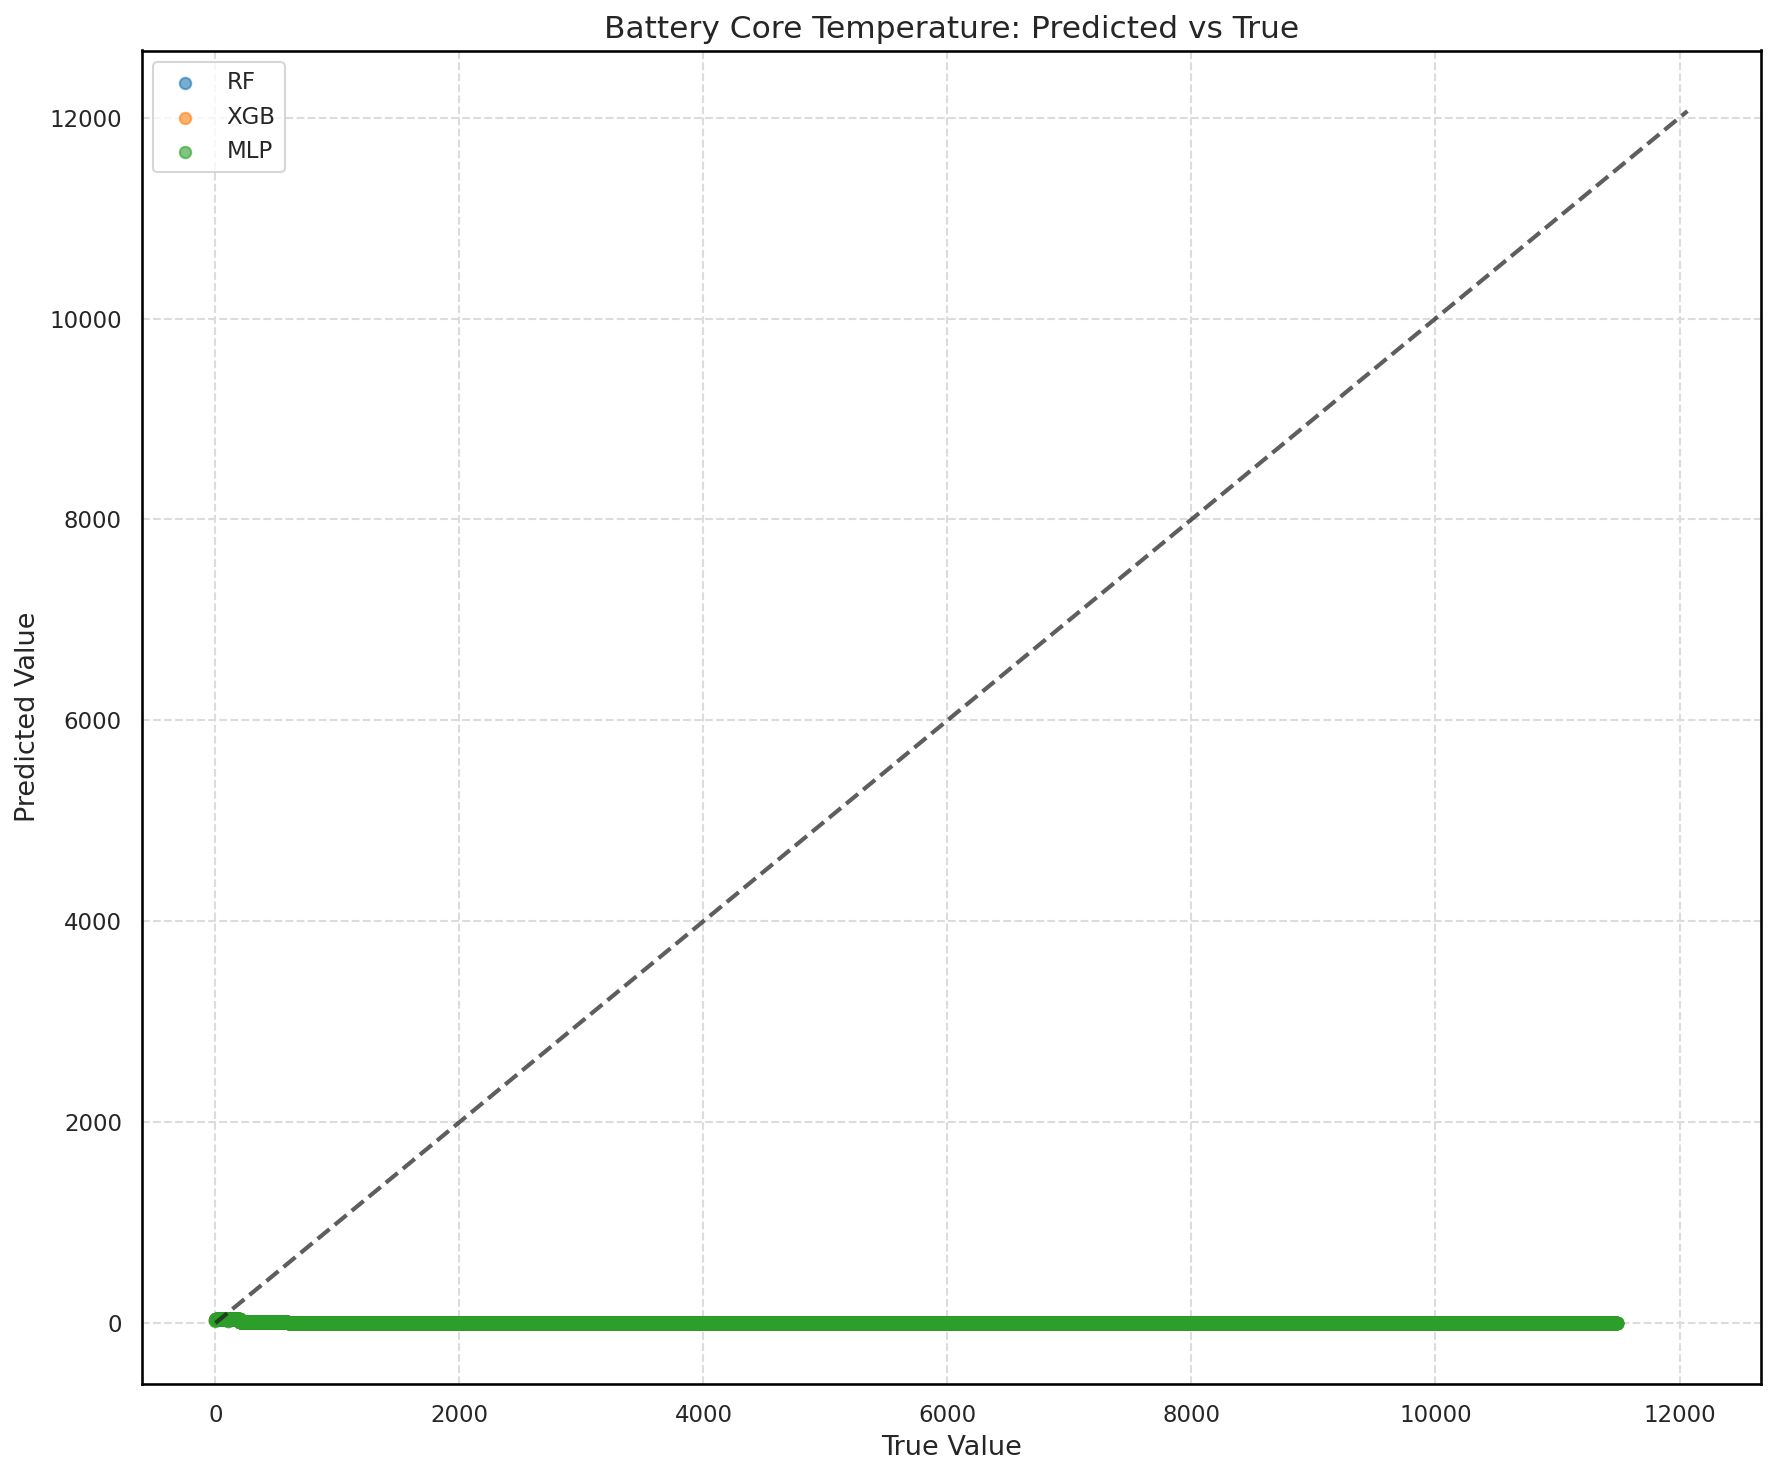

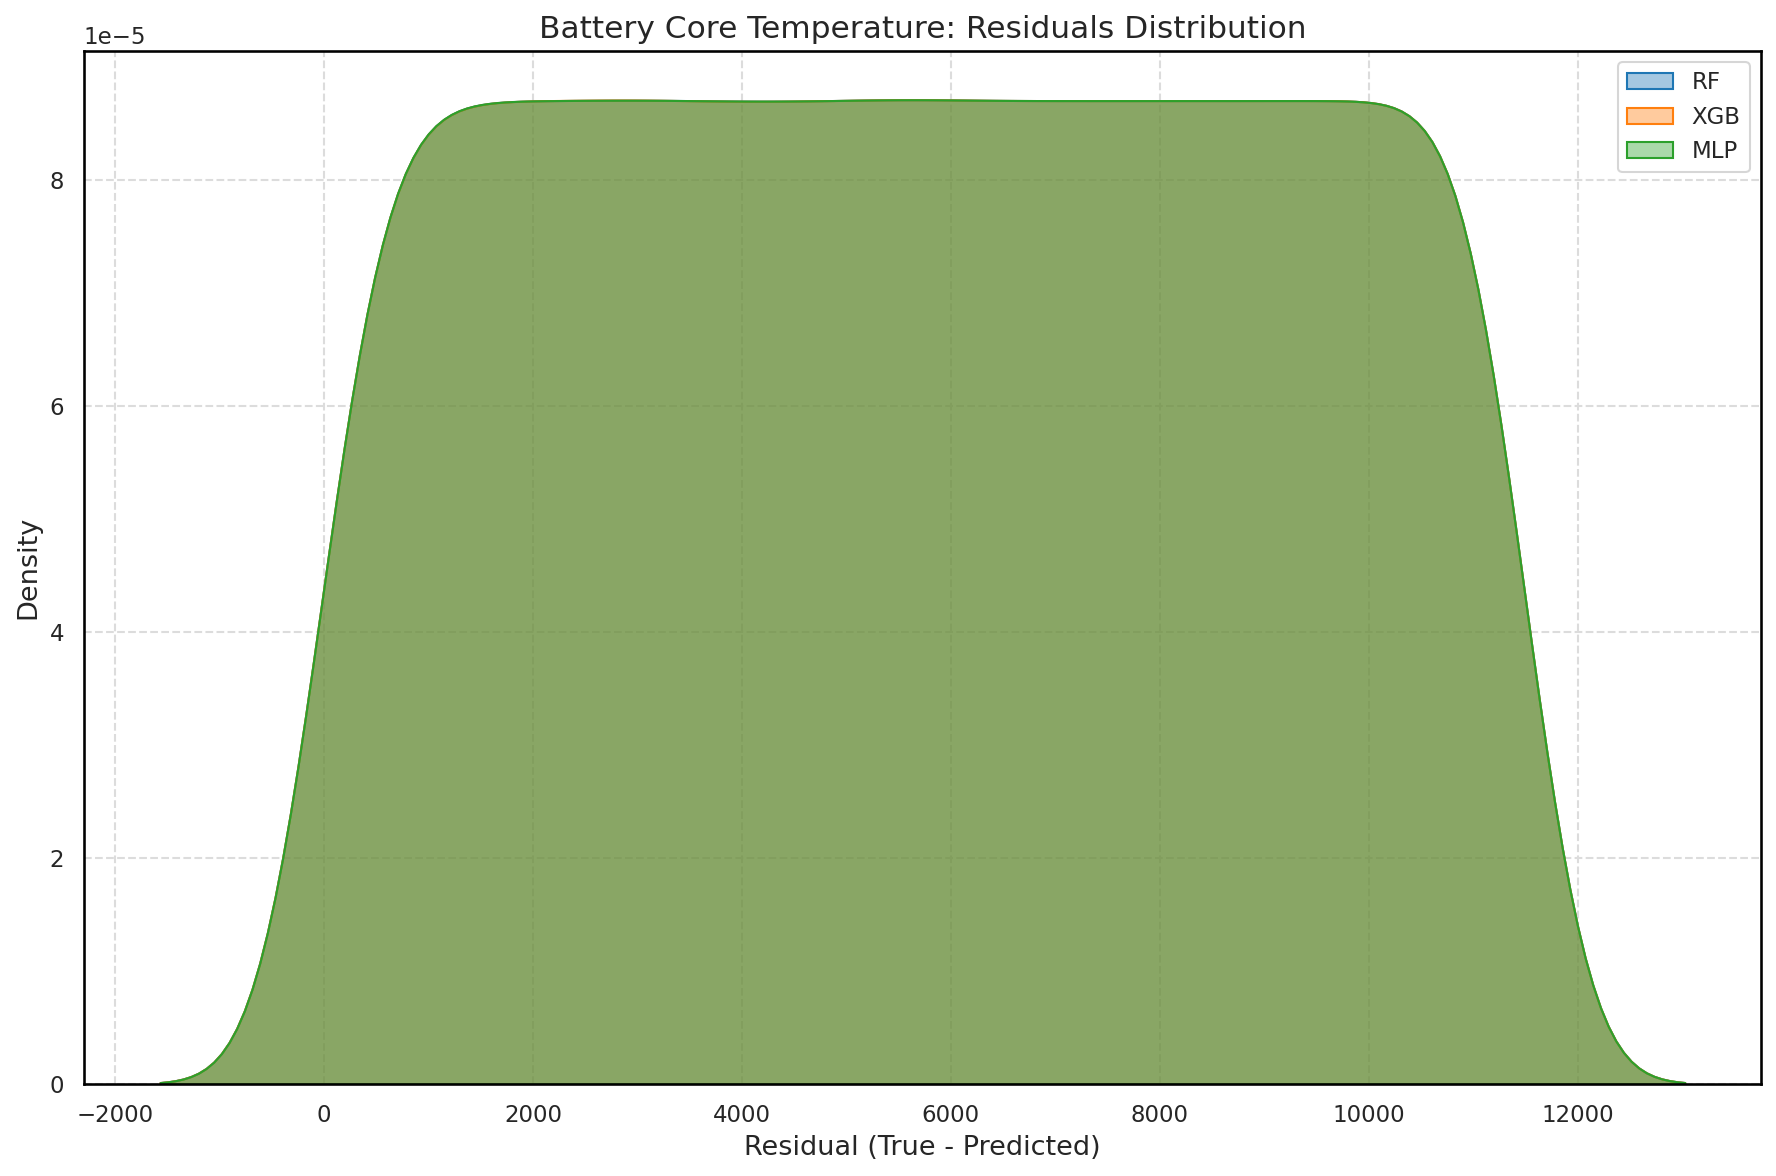

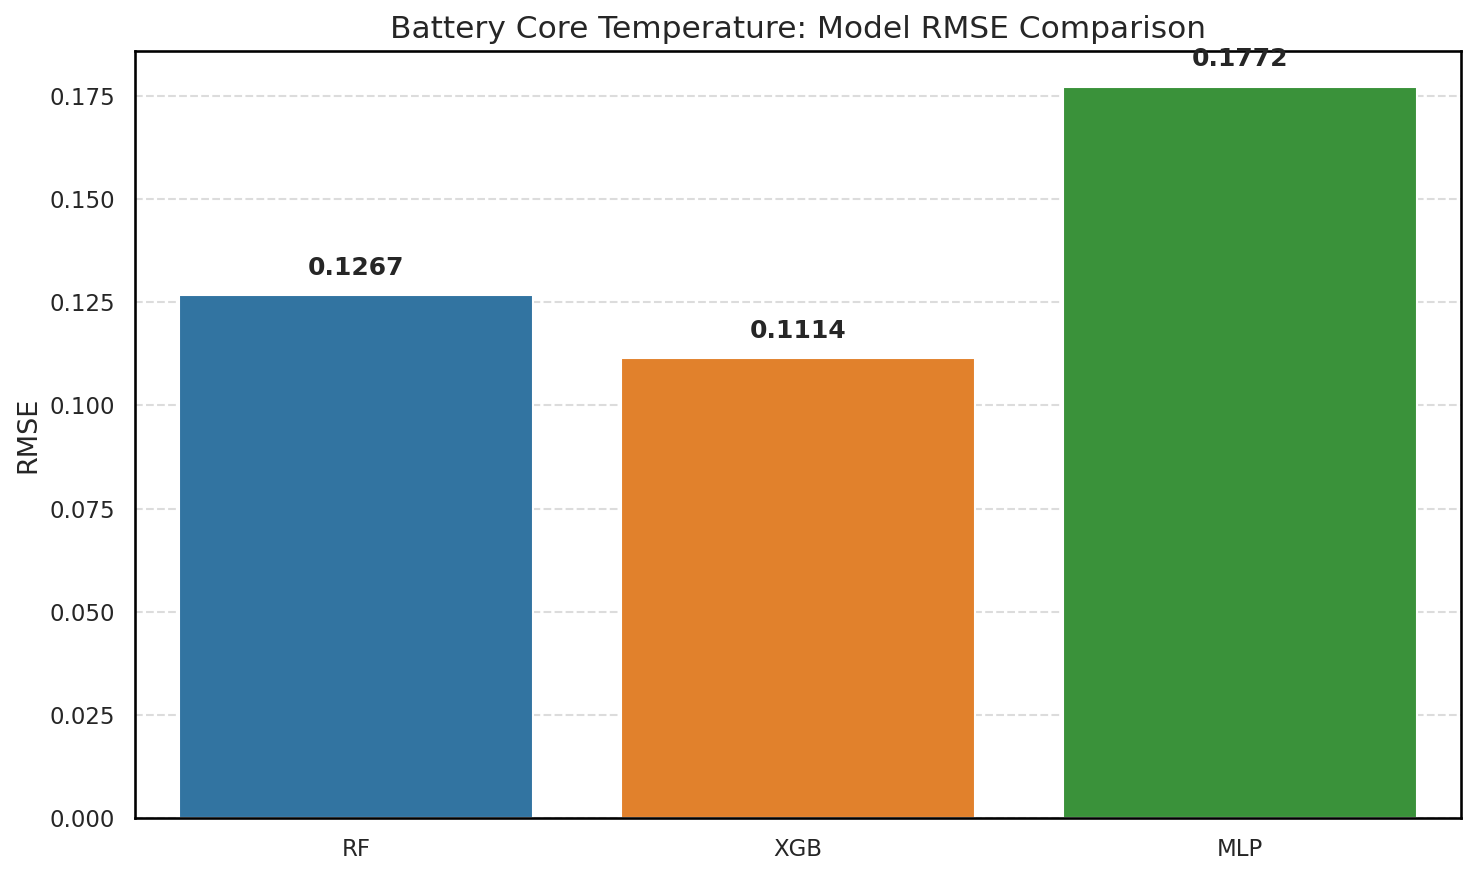

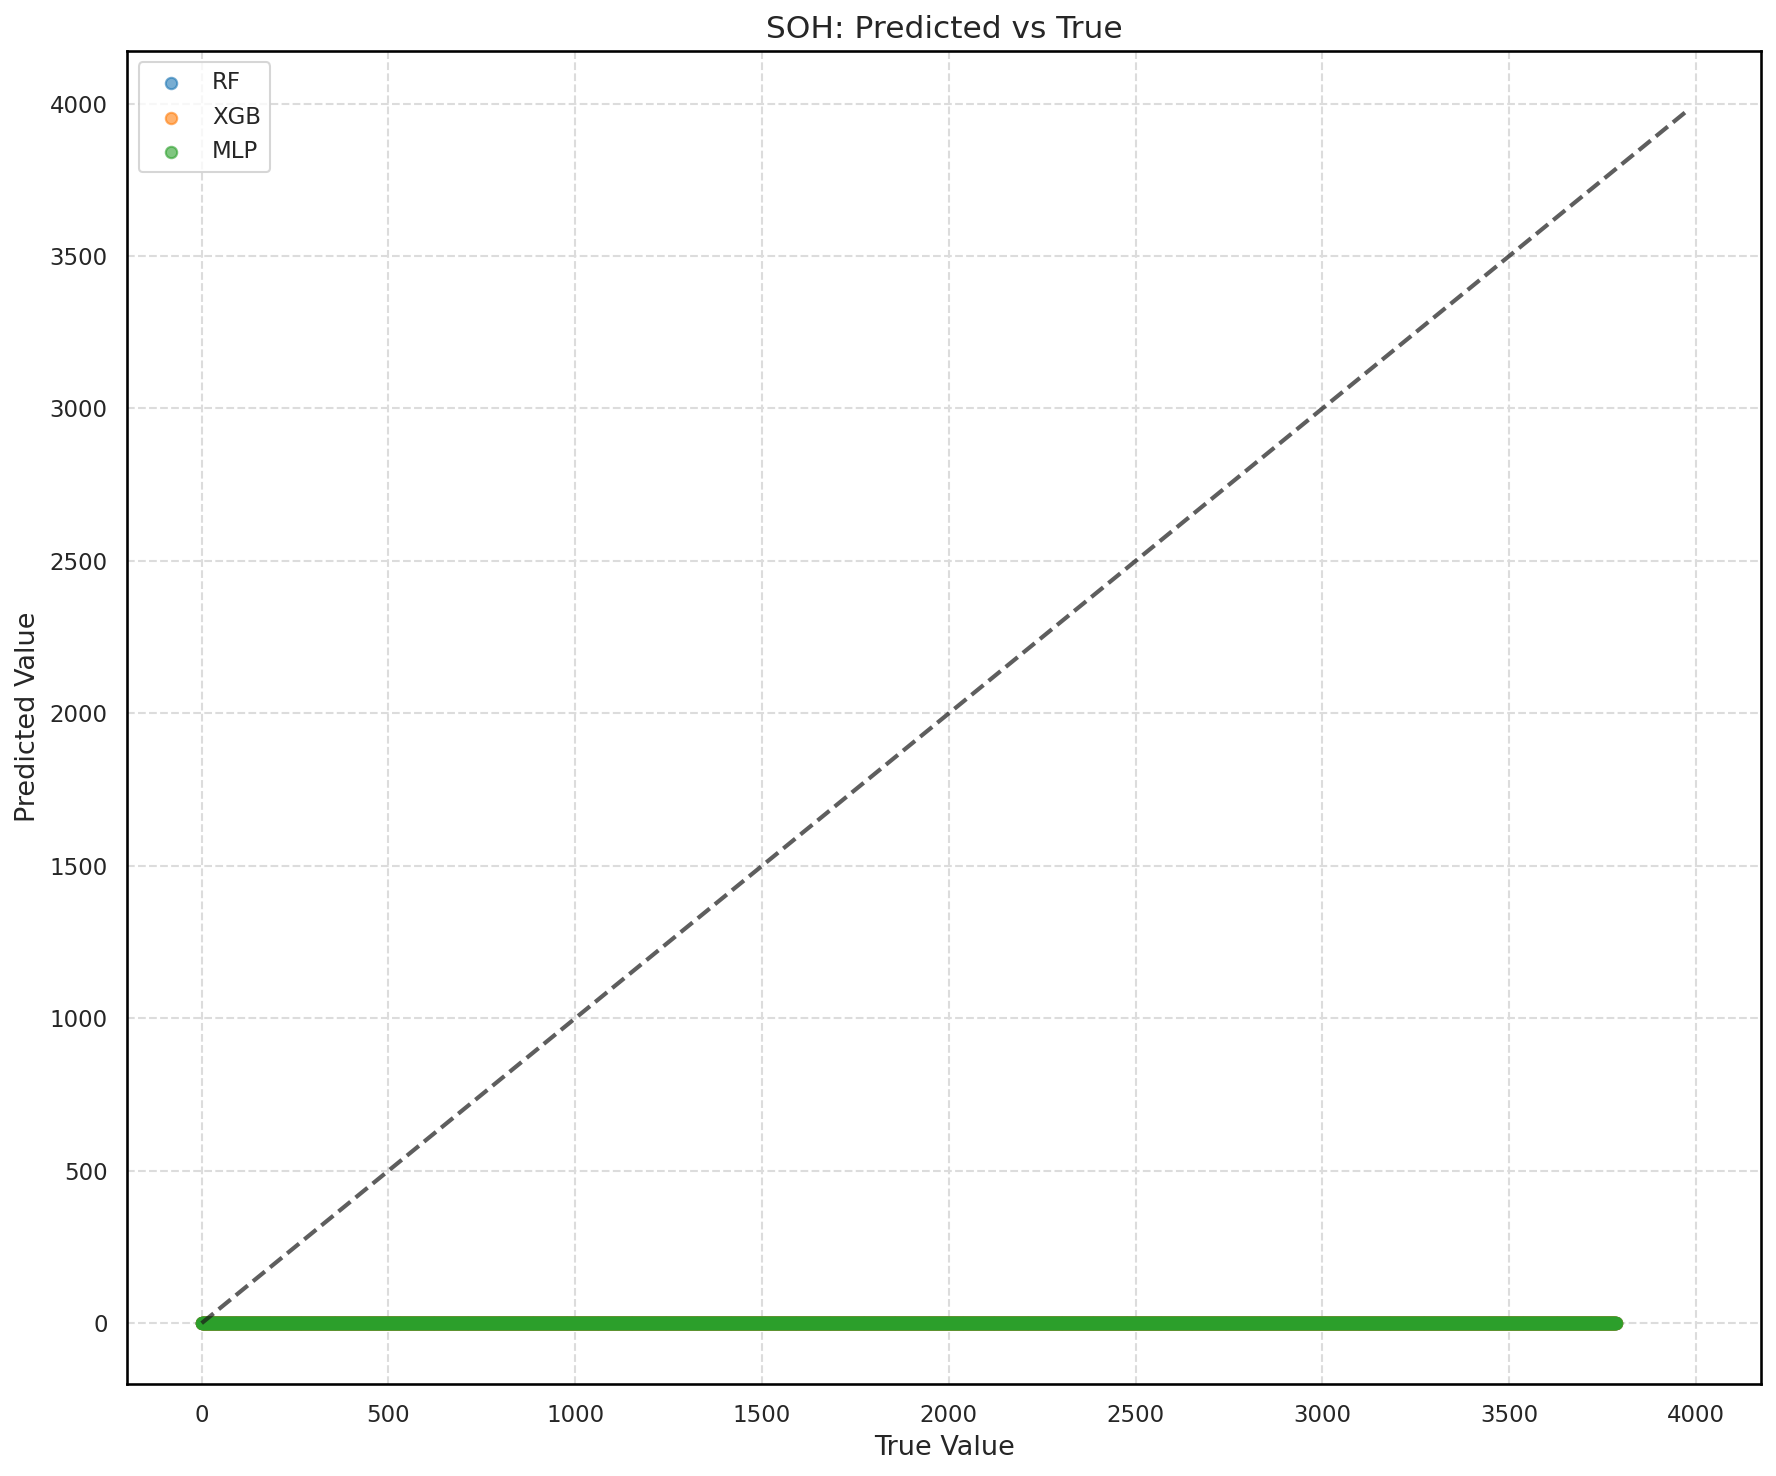

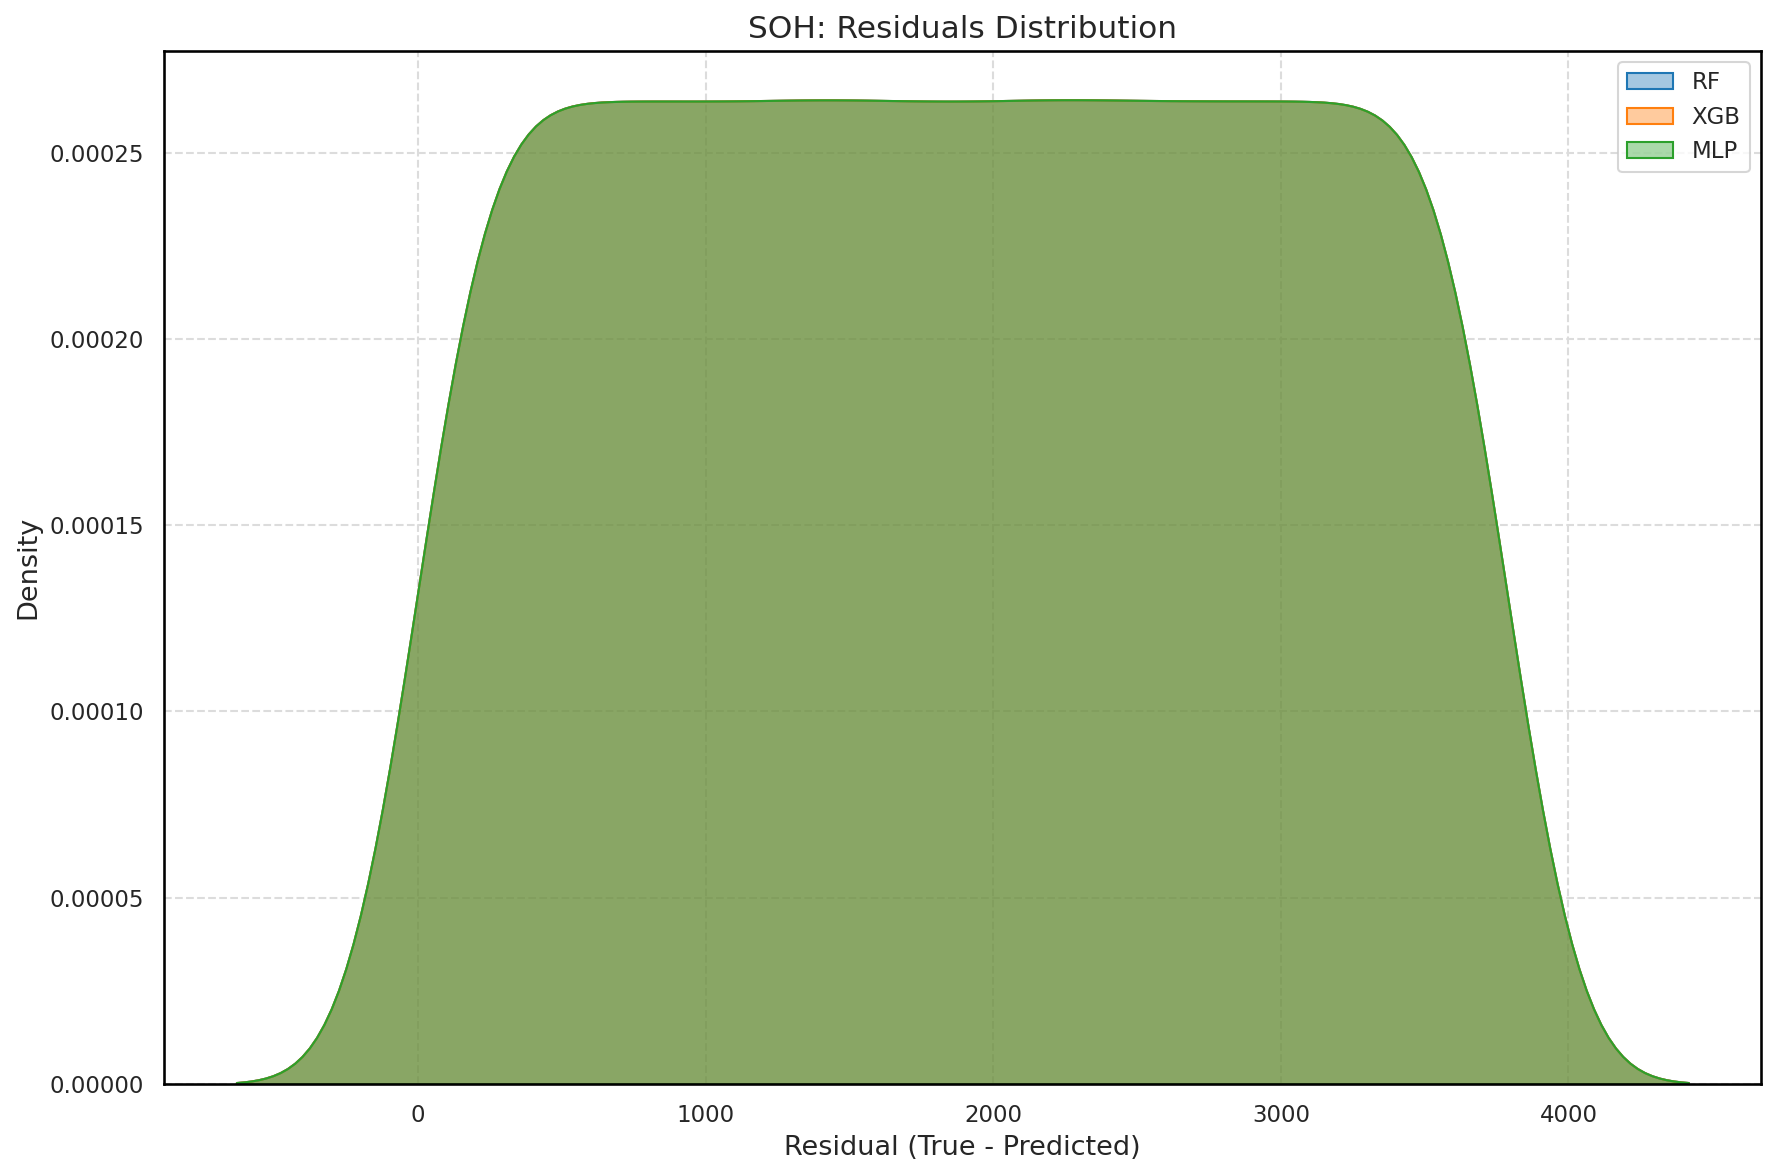

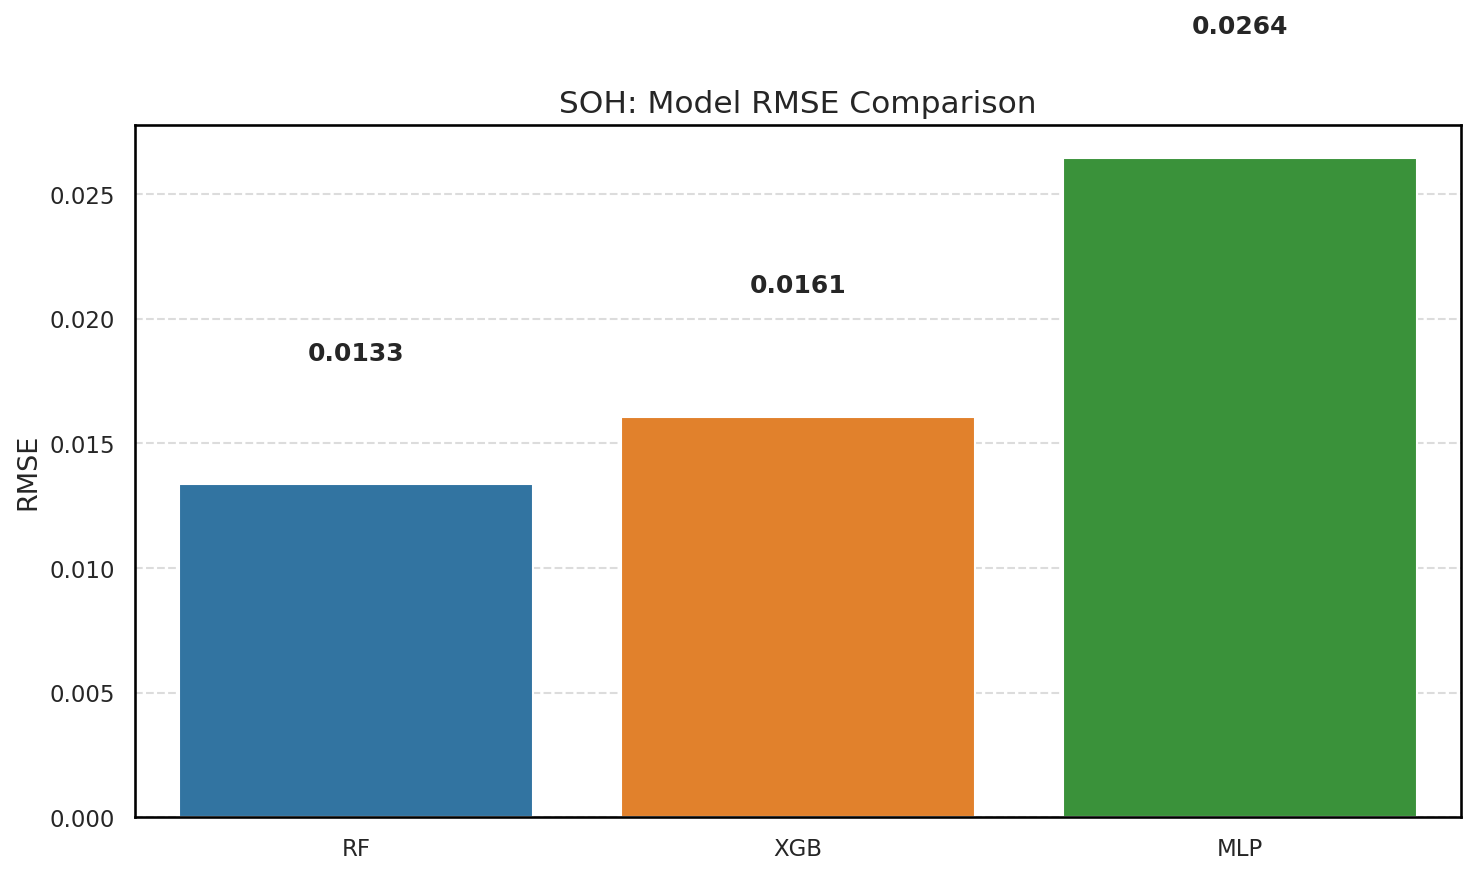

In [7]:
# Plotting Results:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'figure.figsize': (12, 8),
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': True,
    'grid.color': '#dcdcdc',
    'grid.linestyle': '--',
    'font.size': 12,
    'legend.fontsize': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
})

model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
OUT_FOLDER = "figures_week5_7"
os.makedirs(OUT_FOLDER, exist_ok=True)

def generate_visuals(display_name, results_dict):
    """
    Generates multiple plots for a target variable:
    - Predicted vs True
    - Residual distribution
    - RMSE comparison
    """
# Predicted versus True
    fig, ax = plt.subplots(figsize=(12, 10))
    for i, (model_name, res) in enumerate(results_dict['baseline'].items()):
        y_true = res.get('y_test') or res.get('y_true') or np.arange(len(res['y_pred']))
        y_pred = res['y_pred']
        ax.scatter(y_true, y_pred, s=30, alpha=0.6, label=model_name.upper(), color=model_colors[i])

    max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([0, max_val], [0, max_val], 'k--', lw=2, alpha=0.7)
    ax.set_xlabel('True Value')
    ax.set_ylabel('Predicted Value')
    ax.set_title(f'{display_name}: Predicted vs True')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FOLDER, f'pred_vs_true_{display_name}.png'))
    plt.show()

    # Residuals Distribution
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, (model_name, res) in enumerate(results_dict['baseline'].items()):
        y_true = res.get('y_test') or res.get('y_true') or np.arange(len(res['y_pred']))
        y_pred = res['y_pred']
        residuals = y_true - y_pred
        sns.kdeplot(residuals, fill=True, alpha=0.4, label=model_name.upper(), color=model_colors[i], ax=ax)

    ax.set_xlabel('Residual (True - Predicted)')
    ax.set_title(f'{display_name}: Residuals Distribution')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FOLDER, f'residuals_{display_name}.png'))
    plt.show()

    # RMSE Bar Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    model_names, rmses = [], []
    for model_name, res in results_dict['baseline'].items():
        model_names.append(model_name.upper())
        rmses.append(res.get('rmse', np.nan))
    
    sns.barplot(x=model_names, y=rmses, palette=model_colors, ax=ax)
    ax.set_ylabel('RMSE')
    ax.set_title(f'{display_name}: Model RMSE Comparison')
    for i, v in enumerate(rmses):
        ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FOLDER, f'rmse_{display_name}.png'))
    plt.show()

# Generate visuals for both targets
if 'core_results' in globals():
    generate_visuals('Battery Core Temperature', core_results)

if 'soh_results' in globals():
    generate_visuals('SOH', soh_results)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns
import joblib
import warnings
from pathlib import Path
from datetime import datetime
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

warnings.filterwarnings("ignore")

# ── Global Style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'axes.titlesize': 17,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#FAFAFA',
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.color': '#E0E0E0',
    'grid.linewidth': 0.8,
})

# Each model gets its own vivid identity; target tasks get distinct accent tones
MODEL_COLORS = {
    'rf':  '#E63946',   # vivid red   — Random Forest
    'xgb': '#F4A261',   # warm amber  — XGBoost
    'mlp': '#2A9D8F',   # teal        — MLP
}
MODEL_LABELS = {'rf': 'Random Forest', 'xgb': 'XGBoost', 'mlp': 'MLP'}

TARGET_ACCENT = {
    'core': '#457B9D',   # steel blue  — Core Temperature
    'soh':  '#6A4C93',   # deep violet — SOH
}
TARGET_TITLES = {
    'core': 'Battery Core Temperature',
    'soh':  'State of Health (SOH)',
}

FIG_DIR = Path("figures_week5_7")
FIG_DIR.mkdir(exist_ok=True, parents=True)
OUT_DIR = Path("models_week5_7")


def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def _save(fig, name, close=True):
    fp = FIG_DIR / name
    fig.savefig(fp, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    if close:
        plt.close(fig)
    print(f"  ✓ Saved → {fp}")

def _load_y_test(suffix, target_col):
    """Recover y_test from the preproc checkpoint saved during training."""
    preproc_fp = OUT_DIR / f"preproc_{suffix}.joblib"
    if not preproc_fp.exists():
        print(f"  ⚠  preproc_{suffix}.joblib not found — skipping y_test recovery")
        return None
    data = joblib.load(preproc_fp)
    test_df = data['test_df']
    if target_col not in test_df.columns:
        # try to find a close match
        candidates = [c for c in test_df.columns if target_col.split('_')[0] in c]
        if candidates:
            target_col = candidates[0]
        else:
            print(f"  ⚠  target '{target_col}' not in test_df columns")
            return None
    return test_df[target_col].astype(float).values

def _clean_pair(y_true, y_pred):
    """Drop NaN/Inf positions; return (None, None) if lengths differ or nothing valid."""
    y_true = np.array(y_true, dtype=float).ravel()
    y_pred = np.array(y_pred, dtype=float).ravel()
    if y_true.shape[0] != y_pred.shape[0]:
        # Length mismatch — cannot pair; caller should fall back to stored metrics
        return None, None
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 2:
        return None, None
    return y_true[mask], y_pred[mask]

def _safe_metrics(y_true, y_pred, res_dict):
    """Compute RMSE/MAE/R² safely; fall back to stored values on failure."""
    if y_true is not None:
        yt, yp = _clean_pair(y_true, y_pred)
        if yt is not None and len(yt) >= 2:
            try:
                return rmse(yt, yp), mean_absolute_error(yt, yp), r2_score(yt, yp)
            except Exception:
                pass
    return (res_dict.get('rmse', np.nan),
            res_dict.get('mae',  np.nan),
            res_dict.get('r2',   np.nan))

def _collect_metrics(results_dict, y_test):
    """Return a tidy DataFrame of metrics for all baseline and tuned models."""
    rows = []
    for phase in ('baseline', 'tuned'):
        sub = results_dict.get(phase, {})
        for name, res in sub.items():
            y_pred = np.array(res['y_pred'])
            m, ma, r2 = _safe_metrics(y_test, y_pred, res)
            rows.append({
                'phase':   phase.capitalize(),
                'model':   name,
                'label':   MODEL_LABELS.get(name, name.upper()),
                'RMSE':    round(m,  5),
                'MAE':     round(ma, 5),
                'R²':      round(r2, 4),
            })
    return pd.DataFrame(rows)


# FIGURE 1 — Metrics Comparison Dashboard 
def plot_metrics_dashboard(suffix, results_dict, y_test):
    print(f"\n[Fig 1] Metrics Dashboard — {TARGET_TITLES[suffix]}")
    df = _collect_metrics(results_dict, y_test)
    if df.empty:
        print("  ⚠  No metrics to plot."); return

    metrics = ['RMSE', 'MAE', 'R²']
    phases  = df['phase'].unique().tolist()
    n_phases = len(phases)
    accent  = TARGET_ACCENT[suffix]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"{TARGET_TITLES[suffix]} — Model Performance Overview",
                 fontsize=19, fontweight='bold', y=1.02)

    bar_w = 0.35
    x = np.arange(df[df['phase'] == phases[0]]['label'].nunique())
    labels_ordered = df[df['phase'] == phases[0]]['label'].tolist()

    phase_colors = [accent, '#E9C46A']   # main + tuned highlight

    for ax, metric in zip(axes, metrics):
        all_vals_for_metric = []
        for i, phase in enumerate(phases):
            sub = df[df['phase'] == phase].set_index('label').reindex(labels_ordered)
            vals = sub[metric].values.astype(float)
            all_vals_for_metric.extend(vals.tolist())
            offset = (i - (n_phases - 1) / 2) * bar_w
            # Clip extreme values so bars don't blow up the canvas
            vals_clipped = np.where(np.isfinite(vals), vals, np.nan)
            bars = ax.bar(x + offset, vals_clipped, bar_w, label=phase,
                          color=phase_colors[i % len(phase_colors)],
                          edgecolor='white', linewidth=1.2,
                          alpha=0.92, zorder=3)
            # annotate bars
            finite_vals = vals_clipped[np.isfinite(vals_clipped)]
            tick = np.nanmax(np.abs(finite_vals)) * 0.04 if len(finite_vals) else 0
            for bar, val in zip(bars, vals_clipped):
                if val is not None and np.isfinite(val):
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            val + tick,
                            f'{val:.4f}' if metric != 'R²' else f'{val:.3f}',
                            ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(labels_ordered, rotation=15, ha='right')
        ax.set_title(metric, fontsize=15, fontweight='bold')
        ax.set_ylabel(metric)
        # Auto-scale with sensible padding instead of hard-coding 0–1.12
        finite_all = [v for v in all_vals_for_metric if np.isfinite(v)]
        if finite_all:
            lo, hi = min(finite_all), max(finite_all)
            span = max(hi - lo, 1e-6)
            ax.set_ylim(lo - span * 0.15, hi + span * 0.18)
        ax.legend(framealpha=0.9)

    fig.tight_layout()
    _save(fig, f"fig1_metrics_dashboard_{suffix}.png")


# FIGURE 2 — Parity Plots (Predicted vs Actual) per model
def plot_parity(suffix, results_dict, y_test):
    print(f"\n[Fig 2] Parity Plots — {TARGET_TITLES[suffix]}")
    if y_test is None:
        print("  ⚠  y_test unavailable — skipping parity plots"); return

    # Use tuned models if available, else baseline
    source_key = 'tuned' if results_dict.get('tuned') else 'baseline'
    source = results_dict[source_key]
    n_models = len(source)
    if n_models == 0:
        print("  ⚠  No models found."); return

    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 7))
    if n_models == 1:
        axes = [axes]
    fig.suptitle(f"{TARGET_TITLES[suffix]} — Predicted vs Actual  ({source_key.capitalize()})",
                 fontsize=19, fontweight='bold', y=1.02)

    for ax, (name, res) in zip(axes, source.items()):
        y_pred = np.array(res['y_pred'])
        color  = MODEL_COLORS.get(name, '#333333')
        label  = MODEL_LABELS.get(name, name.upper())

        yt, yp = _clean_pair(y_test, y_pred)
        if yt is None or len(yt) < 2:
            ax.set_title(f"{label}\n(insufficient valid data)"); continue

        r2  = r2_score(yt, yp)
        err = rmse(yt, yp)

        # hexbin density scatter for large N, else scatter
        if len(yt) > 2000:
            hb = ax.hexbin(yt, yp, gridsize=50, cmap='YlOrRd',
                           mincnt=1, linewidths=0.2)
            fig.colorbar(hb, ax=ax, label='Count')
        else:
            ax.scatter(yt, yp, s=25, alpha=0.65, color=color,
                       edgecolors='white', linewidths=0.4, zorder=3)

        mn = min(yt.min(), yp.min())
        mx = max(yt.max(), yp.max())
        pad = (mx - mn) * 0.05
        lims = [mn - pad, mx + pad]
        ax.plot(lims, lims, '--', color='#555555', linewidth=1.8, zorder=4, label='Ideal')

        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel('Actual', fontsize=14)
        ax.set_ylabel('Predicted', fontsize=14)
        ax.set_title(label, fontsize=15, fontweight='bold')
        ax.text(0.05, 0.92, f'R² = {r2:.4f}\nRMSE = {err:.4f}',
                transform=ax.transAxes, fontsize=12,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor=color, linewidth=2),
                verticalalignment='top', color=color, fontweight='bold')

    fig.tight_layout()
    _save(fig, f"fig2_parity_{suffix}.png")


# FIGURE 3 — Residual Distribution (KDE overlay, all models)

def plot_residuals(suffix, results_dict, y_test):
    print(f"\n[Fig 3] Residual Distributions — {TARGET_TITLES[suffix]}")
    if y_test is None:
        print("  ⚠  y_test unavailable — skipping residual plots"); return

    source_key = 'tuned' if results_dict.get('tuned') else 'baseline'
    source = results_dict[source_key]
    if not source:
        print("  ⚠  No models found."); return

    # Build residual arrays — guaranteed finite, min 5 points
    all_residuals = {}
    for name, res in source.items():
        y_pred = np.array(res['y_pred'])
        yt, yp = _clean_pair(y_test, y_pred)
        if yt is not None and len(yt) >= 5:
            resid = (yt - yp)
            resid = resid[np.isfinite(resid)]
            if len(resid) >= 5:
                all_residuals[name] = resid

    if not all_residuals:
        print("  ⚠  No valid residuals to plot"); return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"{TARGET_TITLES[suffix]} — Residual Analysis  ({source_key.capitalize()})",
                 fontsize=19, fontweight='bold', y=1.02)
    ax_kde, ax_box = axes


    for name, resid in all_residuals.items():
        color = MODEL_COLORS.get(name, '#333')
        label = MODEL_LABELS.get(name, name.upper())
        sns.kdeplot(resid, ax=ax_kde, fill=True, alpha=0.35, color=color,
                    linewidth=2.2, label=label)
    ax_kde.axvline(0, color='#222', linewidth=1.8, linestyle='--', alpha=0.8, label='Zero error')
    ax_kde.set_xlabel('Residual  (Actual − Predicted)', fontsize=13)
    ax_kde.set_ylabel('Density', fontsize=13)
    ax_kde.set_title('Error Distribution (KDE)', fontsize=15, fontweight='bold')
    ax_kde.legend(framealpha=0.9)

    # ── Box plot — build parallel lists from same ordered keys 
    names_ordered  = list(all_residuals.keys())
    box_data       = [all_residuals[n] for n in names_ordered]
    box_labels_lst = [MODEL_LABELS.get(n, n.upper()) for n in names_ordered]
    box_colors_lst = [MODEL_COLORS.get(n, '#333')    for n in names_ordered]

    bp = ax_box.boxplot(
        box_data,
        labels=box_labels_lst,
        patch_artist=True,
        notch=False,        # notch=True needs bootstrap and can crash on small N
        vert=True,
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'),
    )
    for patch, color in zip(bp['boxes'], box_colors_lst):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax_box.axhline(0, color='#555', linewidth=1.5, linestyle='--', alpha=0.7)
    ax_box.set_ylabel('Residual  (Actual − Predicted)', fontsize=13)
    ax_box.set_title('Residual Box Plots', fontsize=15, fontweight='bold')

    for i, name in enumerate(names_ordered):
        resid = all_residuals[name]
        y_annot = float(np.percentile(resid, 75)) + float(np.std(resid)) * 0.3
        ax_box.text(i + 1, y_annot,
                    f'σ={np.std(resid):.4f}',
                    ha='center', fontsize=9,
                    color=MODEL_COLORS.get(name, '#333'),
                    fontweight='bold')

    fig.tight_layout()
    _save(fig, f"fig3_residuals_{suffix}.png")


# FIGURE 4 — Feature Importance (Permutation, top 15)
def plot_feature_importance(suffix, results_dict):
    print(f"\n[Fig 4] Feature Importance — {TARGET_TITLES[suffix]}")

    # Load test data from checkpoint
    preproc_fp = OUT_DIR / f"preproc_{suffix}.joblib"
    if not preproc_fp.exists():
        print("  ⚠  preproc checkpoint not found — cannot run permutation importance"); return
    data = joblib.load(preproc_fp)
    features_list = data['features_list']
    preproc       = data['preproc']
    test_df       = data['test_df']

    # identify target column
    target_candidates = [c for c in test_df.columns
                         if c not in features_list and c not in
                         ('cell_id', 'cycle', 'dataset', 'chemistry')]
    if not target_candidates:
        print("  ⚠  Cannot identify target column in test_df"); return
    target_col = target_candidates[0]

    X_test_raw = test_df[features_list]
    y_test_raw = test_df[target_col].astype(float)
    X_test_p   = pd.DataFrame(preproc.transform(X_test_raw), columns=features_list)

    # Drop rows where target is NaN (permutation_importance cannot handle them)
    valid_mask = np.isfinite(y_test_raw.values)
    if valid_mask.sum() < 2:
        print("  ⚠  Too few valid target rows for permutation importance"); return
    X_test_p   = X_test_p.iloc[valid_mask].reset_index(drop=True)
    y_test_raw = y_test_raw.values[valid_mask]

    # Pick best baseline tree model (RF preferred)
    source = results_dict.get('tuned') or results_dict.get('baseline', {})
    tree_order = ['rf', 'xgb']
    best_name  = next((n for n in tree_order if n in source), None)
    if best_name is None:
        print("  ⚠  No tree model found for feature importance"); return

    model = source[best_name]['estimator']
    accent = TARGET_ACCENT[suffix]

    
    perm_fp = FIG_DIR / f"perm_importance_{suffix}.png"   
    # We recompute here for a styled figure
    perm = permutation_importance(model, X_test_p, y_test_raw,
                                  n_repeats=15, random_state=42, n_jobs=-1)
    perm_df = pd.DataFrame({
        'feature': features_list,
        'importance_mean': perm.importances_mean,
        'importance_std':  perm.importances_std,
    }).sort_values('importance_mean', ascending=False).head(15)

    # Color gradient: top feature brightest
    n = len(perm_df)
    palette = [plt.cm.plasma(0.85 - 0.6 * i / max(n - 1, 1)) for i in range(n)]

    fig, ax = plt.subplots(figsize=(14, 8))
    y_pos = np.arange(n)
    bars = ax.barh(y_pos, perm_df['importance_mean'].values[::-1],
                   xerr=perm_df['importance_std'].values[::-1],
                   color=palette[::-1], edgecolor='white',
                   linewidth=0.8, alpha=0.92, capsize=4,
                   error_kw=dict(elinewidth=1.2, ecolor='#555555'))
    ax.set_yticks(y_pos)
    ax.set_yticklabels(perm_df['feature'].values[::-1], fontsize=11)
    ax.set_xlabel('Mean Decrease in RMSE  (Permutation Importance)', fontsize=13)
    ax.set_title(f"{TARGET_TITLES[suffix]} — Top {n} Features\n"
                 f"({MODEL_LABELS.get(best_name, best_name.upper())})",
                 fontsize=17, fontweight='bold')

    # Annotate values
    for bar, val in zip(bars, perm_df['importance_mean'].values[::-1]):
        ax.text(bar.get_width() + max(perm_df['importance_mean']) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9.5)

    # colour bar label strip on right
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([f'#{i+1}' for i in range(n)][::-1],
                        fontsize=9, color='#888888')
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    fig.tight_layout()
    _save(fig, f"fig4_feature_importance_{suffix}.png")


# FIGURE 5 — Baseline vs Tuned RMSE Improvement

def plot_tuning_improvement(suffix, results_dict, y_test):
    print(f"\n[Fig 5] Tuning Improvement — {TARGET_TITLES[suffix]}")
    if not results_dict.get('tuned'):
        print("  ⚠  No tuned results — skipping improvement plot"); return

    baseline = results_dict['baseline']
    tuned    = results_dict['tuned']
    common   = [n for n in baseline if n in tuned]
    if not common:
        print("  ⚠  No common models between baseline and tuned"); return

    rows = []
    for name in common:
        b_rmse, _, _ = _safe_metrics(y_test, np.array(baseline[name]['y_pred']), baseline[name])
        t_rmse, _, _ = _safe_metrics(y_test, np.array(tuned[name]['y_pred']),    tuned[name])
        delta  = b_rmse - t_rmse       # positive = improvement
        rows.append({'model': MODEL_LABELS.get(name, name.upper()),
                     'Baseline RMSE': b_rmse,
                     'Tuned RMSE':    t_rmse,
                     'Δ RMSE':        delta,
                     'color': MODEL_COLORS.get(name, '#555')})
    df = pd.DataFrame(rows)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"{TARGET_TITLES[suffix]} — Hyperparameter Tuning Impact",
                 fontsize=19, fontweight='bold', y=1.02)

    ax_bar, ax_delta = axes
    x = np.arange(len(df))

    # Grouped bar: Baseline vs Tuned RMSE
    ax_bar.bar(x - 0.2, df['Baseline RMSE'], 0.38, label='Baseline',
               color='#ADB5BD', edgecolor='white', alpha=0.9)
    ax_bar.bar(x + 0.2, df['Tuned RMSE'],    0.38, label='Tuned',
               color=df['color'], edgecolor='white', alpha=0.9)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(df['model'], fontsize=12)
    ax_bar.set_ylabel('RMSE', fontsize=13)
    ax_bar.set_title('RMSE: Baseline vs Tuned', fontsize=15, fontweight='bold')
    ax_bar.legend(framealpha=0.9)
    for i, (b, t) in enumerate(zip(df['Baseline RMSE'], df['Tuned RMSE'])):
        ax_bar.text(i - 0.2, b + max(df['Baseline RMSE']) * 0.012,
                    f'{b:.4f}', ha='center', fontsize=9)
        ax_bar.text(i + 0.2, t + max(df['Tuned RMSE']) * 0.012,
                    f'{t:.4f}', ha='center', fontsize=9)

    # Delta RMSE lollipop chart
    delta_colors = ['#2A9D8F' if v >= 0 else '#E63946' for v in df['Δ RMSE']]
    ax_delta.hlines(x, 0, df['Δ RMSE'], colors=delta_colors, linewidth=3, alpha=0.8)
    ax_delta.scatter(df['Δ RMSE'], x, s=120, color=delta_colors, zorder=5,
                     edgecolors='white', linewidths=1.5)
    ax_delta.axvline(0, color='#333', linewidth=1.5, linestyle='--', alpha=0.7)
    ax_delta.set_yticks(x)
    ax_delta.set_yticklabels(df['model'], fontsize=12)
    ax_delta.set_xlabel('RMSE Reduction  (Baseline − Tuned)', fontsize=13)
    ax_delta.set_title('Improvement from Tuning\n(green = improved, red = degraded)',
                       fontsize=15, fontweight='bold')
    for i, (xi, val) in enumerate(zip(x, df['Δ RMSE'])):
        ax_delta.text(val + (max(abs(df['Δ RMSE'])) * 0.03),
                      xi, f'{val:+.4f}', va='center', fontsize=10,
                      color=delta_colors[i], fontweight='bold')

    fig.tight_layout()
    _save(fig, f"fig5_tuning_improvement_{suffix}.png")


# FIGURE 6 — Summary Scorecard 

def plot_scorecard(core_results, soh_results, core_y_test, soh_y_test):
    print("\n[Fig 6] Summary Scorecard")

    pairs = []
    for suffix, res, y_test in [('core', core_results, core_y_test),
                                 ('soh',  soh_results,  soh_y_test)]:
        if res is None:
            continue
        source_key = 'tuned' if res.get('tuned') else 'baseline'
        source     = res[source_key]
        for name, r in source.items():
            y_pred = np.array(r['y_pred'])
            err, ma, r2 = _safe_metrics(y_test, y_pred, r)
            pairs.append({
                'Task':   TARGET_TITLES[suffix],
                'Model':  MODEL_LABELS.get(name, name.upper()),
                'Phase':  source_key.capitalize(),
                'RMSE':   err,
                'MAE':    ma,
                'R²':     r2,
            })

    if not pairs:
        print("  ⚠  No data for scorecard"); return

    df = pd.DataFrame(pairs)

    fig = plt.figure(figsize=(18, max(5, len(df) * 0.65 + 2)))
    fig.suptitle("ML Model Performance Summary — All Tasks & Models",
                 fontsize=20, fontweight='bold', y=0.98)
    ax = fig.add_subplot(111)
    ax.axis('off')

    col_labels = ['Task', 'Model', 'Phase', 'RMSE ↓', 'MAE ↓', 'R² ↑']
    cell_text  = []
    cell_colors = []

    # Determine best RMSE per task for highlighting
    best_rmse = df.groupby('Task')['RMSE'].min().to_dict()

    row_base_colors = {
        'Battery Core Temperature': '#EBF5FB',
        'State of Health (SOH)':    '#F5EEF8',
    }
    highlight_color = '#D4EFDF'   # green highlight for best model

    for _, row in df.iterrows():
        is_best = (row['RMSE'] == best_rmse.get(row['Task'], None))
        base    = highlight_color if is_best else row_base_colors.get(row['Task'], 'white')
        cell_text.append([
            row['Task'], row['Model'], row['Phase'],
            f"{row['RMSE']:.5f}", f"{row['MAE']:.5f}", f"{row['R²']:.4f}"
        ])
        cell_colors.append([base] * 6)

    tbl = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellColours=cell_colors,
        cellLoc='center',
        loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(12)
    tbl.scale(1, 1.8)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#2C3E50')
        tbl[0, j].get_text().set_color('white')
        tbl[0, j].get_text().set_fontweight('bold')

    fig.tight_layout()
    _save(fig, "fig6_scorecard_summary.png")

# Running All Figures
def run_all_visuals():
    print("=" * 70)
    print("  CELL 8 — ML Evaluation & Poster Visualization Suite")
    print(f"  {datetime.now().strftime('%Y-%m-%d  %H:%M:%S')}")
    print("=" * 70)

    # Resolve results and y_test for both targets
    pipelines = {}
    for suffix in ('core', 'soh'):
        var_name = f"{suffix}_results"
        res = globals().get(var_name) or (
            core_results if suffix == 'core' and 'core_results' in dir() else
            soh_results  if suffix == 'soh'  and 'soh_results'  in dir() else None
        )
        if res is None:
            continue
        # Recover target column name
        preproc_fp = OUT_DIR / f"preproc_{suffix}.joblib"
        target_col = None
        if preproc_fp.exists():
            data = joblib.load(preproc_fp)
            test_df = data['test_df']
            non_feat = set(data['features_list']) | {'cell_id', 'cycle', 'dataset', 'chemistry'}
            candidates = [c for c in test_df.columns if c not in non_feat]
            if candidates:
                target_col = candidates[0]
        y_test = _load_y_test(suffix, target_col) if target_col else None
        pipelines[suffix] = (res, y_test)

    if not pipelines:
        print("\n  ⚠  No result variables found in globals (core_results / soh_results).")
        print("  Make sure Cells 6 & 7 ran successfully before running Cell 8.\n")
        return

    for suffix, (res, y_test) in pipelines.items():
        print(f"\n{'─'*55}")
        print(f"  TARGET: {TARGET_TITLES[suffix]}")
        print(f"{'─'*55}")
        plot_metrics_dashboard(suffix, res, y_test)
        plot_parity(suffix, res, y_test)
        plot_residuals(suffix, res, y_test)
        plot_feature_importance(suffix, res)
        plot_tuning_improvement(suffix, res, y_test)

    # Combined scorecard
    core_res = pipelines.get('core', (None, None))[0]
    core_yt  = pipelines.get('core', (None, None))[1]
    soh_res  = pipelines.get('soh',  (None, None))[0]
    soh_yt   = pipelines.get('soh',  (None, None))[1]
    plot_scorecard(core_res, soh_res, core_yt, soh_yt)

    print(f"\n{'='*70}")
    print(f"  ✅  All figures saved to → {FIG_DIR.resolve()}")
    print(f"{'='*70}\n")

run_all_visuals()

  CELL 8 — ML Evaluation & Poster Visualization Suite
  2026-03-05  18:31:19

───────────────────────────────────────────────────────
  TARGET: Battery Core Temperature
───────────────────────────────────────────────────────

[Fig 1] Metrics Dashboard — Battery Core Temperature


  ✓ Saved → figures_week5_7/fig1_metrics_dashboard_core.png

[Fig 2] Parity Plots — Battery Core Temperature
  ✓ Saved → figures_week5_7/fig2_parity_core.png

[Fig 3] Residual Distributions — Battery Core Temperature
  ⚠  No valid residuals to plot

[Fig 4] Feature Importance — Battery Core Temperature
  ⚠  Too few valid target rows for permutation importance

[Fig 5] Tuning Improvement — Battery Core Temperature
  ✓ Saved → figures_week5_7/fig5_tuning_improvement_core.png

───────────────────────────────────────────────────────
  TARGET: State of Health (SOH)
───────────────────────────────────────────────────────

[Fig 1] Metrics Dashboard — State of Health (SOH)
  ✓ Saved → figures_week5_7/fig1_metrics_dashboard_soh.png

[Fig 2] Parity Plots — State of Health (SOH)
  ✓ Saved → figures_week5_7/fig2_parity_soh.png

[Fig 3] Residual Distributions — State of Health (SOH)
  ⚠  No valid residuals to plot

[Fig 4] Feature Importance — State of Health (SOH)
  ⚠  Too few valid target rows fo